In [100]:
import pandas as pd

pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import os, sys

sys.path.append(os.path.abspath(".."))

import original_data_work.helper_fn
import importlib

importlib.reload(original_data_work.helper_fn)
from original_data_work.helper_fn import load_data, get_fmc_category_only

In [101]:
df_combined_path = "../../../data/France/processed_data/combined_df.csv"
events_data_path = "../../../data/France/processed_data/events_batch2.csv"
df_sellin, df_sellout = load_data(df_combined_path)
df_sellout = get_fmc_category_only(df_sellout)
df_events = pd.read_csv(events_data_path, low_memory=False)

df_events["date"] = pd.to_datetime(df_events["date"], format="%Y-%m-%d")

In [102]:
holidays_df_path = "../../../data/France/processed_data/holidays.csv"

df_holidays = pd.read_csv(holidays_df_path)
df_holidays["start_date"] = pd.to_datetime(df_holidays["start_date"])
df_holidays["end_date"] = pd.to_datetime(df_holidays["end_date"])

## Analysis on Single Customer

In [103]:
selected_customer = 331626.0
df_selected = df_sellout[df_sellout["customer_name"] == selected_customer]

df_selected = (
    df_selected.groupby("date")["sales_quantity"]
    .sum()
    .reset_index()
    .sort_values("date")
)

In [106]:
def detect_spikes_global(df):
    df = df.copy()

    mean = df["sales_quantity"].mean()
    std = df["sales_quantity"].std()

    df["z_score"] = (df["sales_quantity"] - mean) / std
    df["is_spike"] = df["z_score"] > 4  # threshold adjustable

    return df


df_selected = detect_spikes_global(df_selected)

In [107]:
fig = go.Figure()

# Main line
fig.add_trace(
    go.Scatter(
        x=df_selected["date"],
        y=df_selected["sales_quantity"],
        mode="lines+markers",
        name="Sales",
    )
)

# 🔴 Spike points
spikes = df_selected[df_selected["is_spike"]]

fig.add_trace(
    go.Scatter(
        x=spikes["date"],
        y=spikes["sales_quantity"],
        mode="markers",
        name="Spikes",
        marker=dict(size=10, color="red", symbol="circle"),
    )
)

fig.update_layout(
    title="Daily Sales (Connected Scatter)",
    xaxis_title="Date",
    yaxis_title="Sales Quantity",
    template="plotly_white",
)

fig.show()

In [108]:
selected_customer = "0011t000011b5TiAAI"
df = df_sellout[df_sellout["customer_code"] == selected_customer]

In [109]:
df_selected = df.groupby(["date", "customer_code"], as_index=False).agg(
    {"sales_quantity": "sum"}
)

df_selected = detect_spikes_global(df_selected)

metadata_cols = [
    "customer_code",
    "customer_name",
    "latitude",
    "longitude",
    "route",
    "brand",
    "channel_name",
]

df_meta = df[metadata_cols].drop_duplicates(subset=["customer_code"])
df_selected = df_selected.merge(df_meta, on="customer_code", how="left")
df_selected["latitude"] = round(df_selected["latitude"], 4)
df_selected["longitude"] = round(df_selected["longitude"], 4)

In [110]:
df_event_selected = df_events[
    (df_events["shop_lat"] == df_selected["latitude"][0])
    & (df_events["shop_lon"] == df_selected["longitude"][0])
]

In [111]:
df_selected.query("is_spike == True")

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name
29,2026-01-30,0011t000011b5TiAAI,277.0,4.530295,True,300005.0,48.8834,2.3279,a0D1t000005iLAnEAM,LUCKY STRIKE,COCO


In [112]:
def add_event_data(df_selected, df_events):
    df = df_selected.copy()
    events = df_events.copy()

    # Collapse multiple events per day → unique event days
    event_dates = set(events["date"].dt.date)
    event_dates = set(pd.to_datetime(list(event_dates)))

    # Create helper
    def has_event(d):
        return d in event_dates

    # Add features
    df["event_same_day"] = df["date"].apply(has_event)
    df["event_day_before"] = df["date"].apply(
        lambda d: (d - pd.Timedelta(days=1)) in event_dates
    )
    df["event_day_after"] = df["date"].apply(
        lambda d: (d + pd.Timedelta(days=1)) in event_dates
    )

    return df

In [113]:
df_selected = add_event_data(df_selected, df_event_selected)

In [115]:
df_selected.query("is_spike == True")

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after
29,2026-01-30,0011t000011b5TiAAI,277.0,4.530295,True,300005.0,48.8834,2.3279,a0D1t000005iLAnEAM,LUCKY STRIKE,COCO,True,False,False


In [116]:
fig = go.Figure()

# -----------------------
# 1. Main sales line
# -----------------------
fig.add_trace(
    go.Scatter(
        x=df_selected["date"],
        y=df_selected["sales_quantity"],
        mode="lines+markers",
        name="Sales",
        line=dict(color="steelblue"),
        marker=dict(size=4),
    )
)

# -----------------------
# 2. Spikes only
# -----------------------
spikes = df_selected[df_selected["is_spike"]].copy()

fig.add_trace(
    go.Scatter(
        x=spikes["date"],
        y=spikes["sales_quantity"],
        mode="markers",
        name="Spikes",
        marker=dict(size=10, color="red", symbol="circle"),
        # 🔥 event context attached here
        customdata=spikes[["event_same_day", "event_day_before", "event_day_after"]],
        hovertemplate=(
            "<b>Spike Point</b><br>"
            "Date: %{x}<br>"
            "Sales: %{y}<br><br>"
            "Event Same Day: %{customdata[0]}<br>"
            "Event Day Before: %{customdata[1]}<br>"
            "Event Day After: %{customdata[2]}<br>"
            "<extra></extra>"
        ),
    )
)

# -----------------------
# 3. Layout styling
# -----------------------
fig.update_layout(
    title="Daily Sales with Spikes & Event Context",
    xaxis_title="Date",
    yaxis_title="Sales Quantity",
    template="plotly_white",
    hovermode="closest",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

fig.show()

## Do For All Customers

In [117]:
def process_customer(df_sellout, df_events, customer_name):

    df = df_sellout[df_sellout["customer_name"] == customer_name]

    # --- sales aggregation ---
    df_selected = df.groupby(["date", "customer_code"], as_index=False).agg(
        {"sales_quantity": "sum"}
    )

    df_selected = detect_spikes_global(df_selected)

    # --- metadata ---
    metadata_cols = [
        "customer_code",
        "customer_name",
        "latitude",
        "longitude",
        "route",
        "brand",
        "channel_name",
    ]

    df_meta = df[metadata_cols].drop_duplicates(subset=["customer_code"])
    df_selected = df_selected.merge(df_meta, on="customer_code", how="left")

    df_selected["latitude"] = df_selected["latitude"].round(4)
    df_selected["longitude"] = df_selected["longitude"].round(4)

    # --- event filtering (FIXED) ---
    df_event_selected = df_events.merge(
        df_selected[["latitude", "longitude"]].drop_duplicates(),
        left_on=["shop_lat", "shop_lon"],
        right_on=["latitude", "longitude"],
        how="inner",
    )

    df_event_selected = df_event_selected.drop(columns=["latitude", "longitude"])

    # --- add event features ---
    df_selected = add_event_data(df_selected, df_event_selected)

    return df_selected

In [118]:
results = []
total_customers = len(df_sellout["customer_name"].unique())
cur_customer = 0
for customer in df_sellout["customer_name"].unique():
    print(f"Processing customer {cur_customer}/{total_customers}: {customer}")
    try:
        res = process_customer(df_sellout, df_events, customer)
        results.append(res)
    except Exception as e:
        print(f"Error for customer {customer}: {e}")

final_df = pd.concat(results, ignore_index=True)

Processing customer 0/604: 576579.0
Processing customer 0/604: 301002.0
Processing customer 0/604: 307057.0
Processing customer 0/604: 304001.0
Processing customer 0/604: 331715.0
Processing customer 0/604: 302010.0
Processing customer 0/604: 304029.0
Processing customer 0/604: 308183.0
Processing customer 0/604: 302007.0
Processing customer 0/604: 305189.0
Processing customer 0/604: 304148.0
Processing customer 0/604: 306139.0
Processing customer 0/604: 305033.0
Processing customer 0/604: 303082.0
Processing customer 0/604: 302198.0
Processing customer 0/604: 305002.0
Processing customer 0/604: 309036.0
Processing customer 0/604: 308100.0
Processing customer 0/604: 301027.0
Processing customer 0/604: 301029.0
Processing customer 0/604: 308003.0
Processing customer 0/604: 304083.0
Processing customer 0/604: 302172.0
Processing customer 0/604: 304081.0
Processing customer 0/604: 576209.0
Processing customer 0/604: 306097.0
Processing customer 0/604: 309223.0
Processing customer 0/604: 3

In [120]:
temp = final_df[final_df["customer_name"] == 331626.0].copy()

temp[temp["is_spike"]]

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after


In [121]:
# final_df.to_csv(
#     "../../../data/France/processed_data/df_events_with_sellout_customer_level.csv",
#     index=False,
# )

## Analysis of Event Data

In [122]:
spike_df = final_df[final_df["is_spike"] == True].copy()

In [123]:
def classify_spike(row):
    if row["event_same_day"]:
        return "event_same_day"
    elif row["event_day_before"]:
        return "event_day_before"
    elif row["event_day_after"]:
        return "event_day_after"
    else:
        return "no_event"


spike_df["spike_cause"] = spike_df.apply(classify_spike, axis=1)

In [124]:
spike_df["spike_cause"].value_counts(normalize=True)

spike_cause
no_event            0.717391
event_same_day      0.152174
event_day_before    0.086957
event_day_after     0.043478
Name: proportion, dtype: float64

In [125]:
## Per customer breakdown.
customer_event_effect = spike_df.groupby("customer_code")[
    ["event_same_day", "event_day_before", "event_day_after"]
].mean()

In [126]:
spike_counts = spike_df.groupby("customer_code").size()

customer_event_effect["spike_count"] = spike_counts

In [127]:
customer_event_effect.sort_values("event_same_day", ascending=False)

,event_same_day,event_day_before,event_day_after,spike_count
customer_code,,,,
0011t000011b4hUAAQ,1.0,0.0,1.0,1
0011t000011b2f5AAA,1.0,1.0,0.0,1
0011t000011b3fWAAQ,1.0,1.0,1.0,1
0011t000011bAvmAAE,1.0,1.0,0.0,1
0011t000011b1uQAAQ,1.0,0.0,1.0,1
0011t000011b9RmAAI,1.0,0.0,0.0,1
0011t000011b5TiAAI,1.0,0.0,0.0,1
0011t000011b4nxAAA,0.0,0.0,0.0,1
0011t000011b4zRAAQ,0.0,0.0,0.0,1


In [128]:
cause_counts = spike_df["spike_cause"].value_counts().reset_index()
cause_counts.columns = ["spike_cause", "count"]

In [129]:
fig = px.bar(
    cause_counts.sort_values("count", ascending=False),
    x="spike_cause",
    y="count",
    text="count",
    title="Spike Causes Distribution",
)

fig.update_traces(textposition="outside")
fig.show()

In [130]:
total_spikes = len(spike_df)
spike_per_shop = (
    spike_df.groupby("customer_code")["date"].count().sort_values(ascending=False)
)
spike_gr_then_1 = spike_per_shop[spike_per_shop > 1]
len(spike_gr_then_1)

2

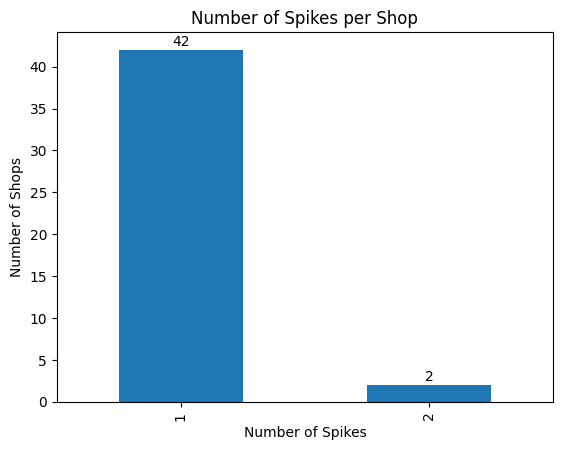

In [131]:
ax = spike_per_shop.value_counts().plot(kind="bar")

# Add values on top of bars
for i, v in enumerate(spike_per_shop.value_counts()):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.title("Number of Spikes per Shop")
plt.xlabel("Number of Spikes")
plt.ylabel("Number of Shops")

plt.show()

In [132]:
spike_gr_then_1.head()

customer_code
0011t000011b4J5AAI    2
0011t000011b1xXAAQ    2
Name: date, dtype: int64

In [133]:
spike_df[spike_df["customer_code"] == "0011t000011b4J5AAI"]

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after,spike_cause
45461,2026-03-10,0011t000011b4J5AAI,321.0,6.836048,True,309154.0,48.8704,2.36,a0D1t000005iLBVEA2,LUCKY STRIKE,COCO,False,False,False,no_event
45473,2026-03-24,0011t000011b4J5AAI,233.0,4.684082,True,309154.0,48.8704,2.36,a0D1t000005iLBVEA2,LUCKY STRIKE,COCO,False,False,False,no_event


In [136]:
spike_df[spike_df["customer_code"] == "0011t000011b1xXAAQ"]

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after,spike_cause
38247,2026-01-12,0011t000011b1xXAAQ,66.0,4.158494,True,307125.0,48.8768,2.372,a0D1t000005iLBVEA2,VOGUE,COCO,False,False,False,no_event
38262,2026-01-29,0011t000011b1xXAAQ,70.0,4.526833,True,307125.0,48.8768,2.372,a0D1t000005iLBVEA2,VOGUE,COCO,False,False,False,no_event


In [146]:
spike_df

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after,spike_cause
923,2026-03-15,0011t000011bBYUAA2,95.0,4.775322,True,304148.0,48.8399,2.3354,a0D1t000005iLAAEA2,LUCKY STRIKE,COCO,False,False,False,no_event
1443,2026-01-24,0011t000011b1ZTAAY,82.0,4.040039,True,308100.0,48.8389,2.3404,a0D1t000005iLAAEA2,LUCKY STRIKE,COCO,False,False,True,event_day_after
2649,2026-03-01,0011t000011b5ddAAA,181.0,4.096897,True,305082.0,48.8584,2.2554,a0D1t000005iL9pEAE,LUCKY STRIKE,COCO,False,False,False,no_event
3425,2026-03-03,0011t000011bB2XAAU,82.0,4.751902,True,306096.0,48.8336,2.3095,a0D1t000005iL9pEAE,LUCKY STRIKE,Independent,False,False,False,no_event
5403,2026-01-25,0011t000011b4R6AAI,60.0,4.039021,True,307105.0,48.8697,2.3534,a0D1t000005iLAGEA2,LUCKY STRIKE,COCO,False,True,True,event_day_before
5726,2026-03-22,0011t000011b4zRAAQ,82.0,4.636051,True,306080.0,48.8454,2.2978,a0D1t000005iL9pEAE,WINFIELD,COCO,False,False,False,no_event
5773,2026-02-07,0011t000011bB2VAAU,227.0,6.361361,True,304220.0,48.8584,2.3476,a0D1t000005iLAGEA2,LUCKY STRIKE,COCO,False,False,True,event_day_after
5994,2026-03-22,0011t000011b4nxAAA,130.0,4.052148,True,301070.0,48.8834,2.3346,a0D1t000005iLAnEAM,LUCKY STRIKE,COCO,False,False,False,no_event
7348,2026-03-17,0011t000011b1uRAAQ,89.0,4.366139,True,576745.0,48.8978,2.3760,a0D1t000005iLBVEA2,ROTHMANS,COCO,False,False,False,no_event
8230,2026-02-26,0011t000011b23oAAA,117.0,5.291797,True,305085.0,48.8584,2.2554,a0D1t000005iL9pEAE,LUCKY STRIKE,COCO,False,False,False,no_event


In [138]:
# 2nd Feb, 3rd, and 21st March
# 21 Jan, 13 Feb, 27 Mar
# 20th Jan, 13th Feb, 13th Mar
# 5th Jan, 30th Jan, 5th Feb
# 22nd Jan, 7th Feb, 18th Mar

In [139]:
spike_by_date = spike_df.groupby("date").is_spike.sum().sort_values(ascending=False)

## Analysis with Holidays

In [140]:
df_expanded = df_holidays.loc[
    df_holidays.index.repeat(
        (df_holidays["end_date"] - df_holidays["start_date"]).dt.days + 1
    )
].copy()

# Fix: use timedelta
df_expanded["date"] = df_expanded["start_date"] + pd.to_timedelta(
    df_expanded.groupby(level=0).cumcount(), unit="D"
)

# Keep only needed columns
df_expanded = df_expanded[["date", "name", "type", "id"]]

In [141]:
df_merged = spike_df.merge(df_expanded, on="date", how="left")

df_merged["is_holiday"] = df_merged["type"].notnull()

In [142]:
df_merged.head()

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after,spike_cause,name,type,id,is_holiday
0,2026-03-15,0011t000011bBYUAA2,95.0,4.775322,True,304148.0,48.8399,2.3354,a0D1t000005iLAAEA2,LUCKY STRIKE,COCO,False,False,False,no_event,NaN,NaN,NaN,False
1,2026-01-24,0011t000011b1ZTAAY,82.0,4.040039,True,308100.0,48.8389,2.3404,a0D1t000005iLAAEA2,LUCKY STRIKE,COCO,False,False,True,event_day_after,NaN,NaN,NaN,False
2,2026-03-01,0011t000011b5ddAAA,181.0,4.096897,True,305082.0,48.8584,2.2554,a0D1t000005iL9pEAE,LUCKY STRIKE,COCO,False,False,False,no_event,Winter Holidays,School,4039a322-b417-48e1-a751-a4bd133f2b06,True
3,2026-03-03,0011t000011bB2XAAU,82.0,4.751902,True,306096.0,48.8336,2.3095,a0D1t000005iL9pEAE,LUCKY STRIKE,Independent,False,False,False,no_event,NaN,NaN,NaN,False
4,2026-01-25,0011t000011b4R6AAI,60.0,4.039021,True,307105.0,48.8697,2.3534,a0D1t000005iLAGEA2,LUCKY STRIKE,COCO,False,True,True,event_day_before,NaN,NaN,NaN,False


In [143]:
df_spike_by_date = spike_by_date.reset_index()
df_spike_by_date.columns = ["date", "spike_count"]

df_spike_by_date["date"] = pd.to_datetime(df_spike_by_date["date"])

df_holidays_small = df_expanded[["date", "name", "type"]].copy()

df_holiday_and_date = df_spike_by_date.merge(df_holidays_small, on="date", how="left")
df_holiday_and_date["is_holiday"] = df_holiday_and_date["name"].notna().astype(int)

In [144]:
df_holiday_and_date["holiday_flag"] = df_holiday_and_date["is_holiday"].map(
    {0: "No Holiday", 1: "Holiday"}
)

# sort by date (important for bar charts)
df_plot = df_holiday_and_date.sort_values("date")
df_plot = df_plot[df_plot["spike_count"] > 3]

fig = px.bar(
    df_plot,
    x="date",
    y="spike_count",
    color="holiday_flag",
    hover_data=["name", "type"],
    title="Spike Count Over Time (Holiday vs Non-Holiday)",
    height=600,
)

fig.show()

In [145]:
df_holiday_and_date

,date,spike_count,name,type,is_holiday,holiday_flag
0,2026-01-30,6,NaN,NaN,0,No Holiday
1,2026-03-03,4,NaN,NaN,0,No Holiday
2,2026-03-17,3,NaN,NaN,0,No Holiday
3,2026-01-24,3,NaN,NaN,0,No Holiday
4,2026-02-13,2,NaN,NaN,0,No Holiday
5,2026-01-15,2,NaN,NaN,0,No Holiday
6,2026-03-22,2,NaN,NaN,0,No Holiday
7,2026-03-10,2,NaN,NaN,0,No Holiday
8,2026-02-28,2,Winter Holidays,School,1,Holiday
9,2026-03-26,2,NaN,NaN,0,No Holiday


## Looking for Trade Promotion

In [66]:
# Trade promotion when a single date has spike over 5-shops.
trade_promotion_value = 4
df_trade_promotion_dates = df_holiday_and_date[
    df_holiday_and_date["spike_count"] > trade_promotion_value
]
df_non_trade_promotion_dates = df_holiday_and_date[
    df_holiday_and_date["spike_count"] <= trade_promotion_value
]

df_trade_promotion_dates.shape, df_non_trade_promotion_dates.shape

((24, 6), (58, 6))

In [71]:
print(
    "Total Spikes due to Trade Promotion: ", df_trade_promotion_dates.spike_count.sum()
)
print("Spikes due to other reasons: ", df_non_trade_promotion_dates.spike_count.sum())

Total Spikes due to Trade Promotion:  148
Spikes due to other reasons:  122


#### Now let's analyze the 122 non trade promotion spikes

In [75]:
df_ntp = df_merged[df_merged["date"].isin(df_non_trade_promotion_dates["date"])]

df_ntp.shape

(122, 19)

In [79]:
df_ntp["spike_cause"] = df_ntp.apply(classify_spike, axis=1)

/tmp/ipykernel_3929/2691854161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ntp["spike_cause"] = df_ntp.apply(classify_spike, axis=1)


In [87]:
final_df = (
    df_ntp["spike_cause"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "spike_cause", "spike_cause_final": "count"})
)

In [88]:
final_df.head()

,spike_cause,count
0,no_event,78
1,event_same_day,18
2,event_day_before,17
3,event_day_after,9


In [90]:
fig = px.bar(
    final_df.sort_values("count", ascending=False),
    x="spike_cause",
    y="count",
    text="count",
    title="Spike Causes Distribution",
)

fig.update_traces(textposition="outside")

fig.update_layout(yaxis=dict(range=[0, final_df["count"].max() * 1.15]))

fig.show()

In [99]:
spike_df[spike_df["customer_code"] == "0011t000011b5TiAAI"]

,date,customer_code,sales_quantity,z_score,is_spike,customer_name,latitude,longitude,route,brand,channel_name,event_same_day,event_day_before,event_day_after,spike_cause
12204,2026-01-30,0011t000011b5TiAAI,277.0,4.530295,True,300005.0,48.8834,2.3279,a0D1t000005iLAnEAM,LUCKY STRIKE,COCO,True,False,False,event_same_day
